In [2]:
import os
import pickle
import pandas as pd
    
import matplotlib.pyplot as plt
import seaborn as sns

# directory of CSV files
shap_directory = "/home/guillen/Conference Paper SHAP Maciej actualizado/Diabetes/shap"

parquet_directory = "/home/guillen/Conference Paper SHAP Maciej actualizado/Diabetes/shap"

scoringResults_directory = ''

sorted_orderScore = pd.DataFrame()

In [3]:
scoringResults_directory = ''

sorted_orderScore = []

sorted_orderScore = pd.read_csv(scoringResults_directory+"shap_orderScore_lr.csv")

sorted_orderScore.drop("Unnamed: 0",axis=1,inplace = True)

sorted_orderScore

sorted_orderScore["Sorted_Features"][0]

## Max density values

SHAP value for max KDE (for each feature) - to change, right now its max bar from histogram, a bit generalized maxShap 

In [4]:
maxDensityValues = pd.read_csv(scoringResults_directory+"shap_maxDensityValues_lr.csv")
maxDensityValues.drop("Unnamed: 0",axis=1,inplace = True)

maxDensityValues[:10]

maxDensityValues.columns

maxDensityValues[['imbalanceRatio', 'feature', 'freq1']]

In [5]:
# Group by 'imbalanceRatio' and compute statistics for 'freq1'
freq1Statistics = (
    maxDensityValues.groupby(["imbalanceRatio", 'feature'])
    .agg(
        median=("freq1", "median"),
        mean=("freq1", "mean"),
        std=("freq1", "std"),
        iqr=("freq1", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
)

freq1Statistics.reset_index(inplace=True)

df_melted = freq1Statistics.melt(id_vars=["imbalanceRatio"], var_name="Statistic", value_name="Value")

# Reset index to prepare for plotting
df_reset = freq1Statistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalanceRatio"].unique():
    subset = df_reset[df_reset["imbalanceRatio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)  # median chart
    plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)  # mean chart
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)  # std chart
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)  # iqr chart

plt.xticks(rotation=90)
plt.title("Dotted Chart for mean by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Reset index to prepare for plotting
df_reset = freq1Statistics.reset_index()

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalanceRatio"].unique():
    subset = df_reset[df_reset["imbalanceRatio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
    plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for STD by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

IR1 - 2%
IR2 - 5%
IR5 - 20%

-- STD results are proportional/similar to IQR
-- Lower Imbalance ratio, the model provides better consistency regarding XAI results. STD is 2x lower than for IR 1
    -- it is true especially for the most important features, these one have the most differences between the IR
    
-- If the mean is similar between IR, and std is different. It means that model is aiming at the same values, hovewer is getting more confused/mistaken with growing IR 

## END of part I

***
***
***
## Features ranking based on position/order/significance

sorted_orderScore[:3]

In [12]:
sorted_orderScore[sorted_orderScore['Indicator']=='orderMean'][['imbalanceRatio', 'Subset', 'Indicator', 'Sorted_Features']]

def extract_top_features(dataframe, column_name, top_features_amount):
    """
    Extract the top X features from the specified column in the DataFrame and add them as a new column.

    Parameters:
        dataframe (pd.DataFrame): Input DataFrame.
        column_name (str): Name of the column containing feature lists as strings.
        top_features_amount (int): Number of top features to extract.

    Returns:
        pd.DataFrame: DataFrame with an additional column containing the top X features as lists.
    """
    dataframe[f'top_{top_features_amount}_features'] = dataframe[column_name].apply(
        lambda x: eval(x)[:top_features_amount]
    )
    return dataframe





# use of extract_top_features 
df = sorted_orderScore[sorted_orderScore['Indicator']=='orderMean'][['imbalanceRatio', 'Subset', 'Indicator', 'Sorted_Features']].copy()

# Define the number of top features to extract
top_features_amount = 5

# Apply the function to extract top features
orderIndicator = extract_top_features(df, "Sorted_Features", top_features_amount)

def calculate_unique_feature_lists_per_group(dataframe, group_column, list_column):
    """
    Calculate unique lists in the specified column of the DataFrame for each group.

    Parameters:
        dataframe (pd.DataFrame): Input DataFrame.
        group_column (str): Name of the column to group by.
        list_column (str): Name of the column containing feature lists as strings or lists.

    Returns:
        pd.DataFrame: DataFrame with columns for group values and unique feature lists.
    """
    unique_lists_per_group = []

    # Group by the specified column
    for group, group_df in dataframe.groupby(group_column):
        # Convert each list in the column to a tuple (to account for order sensitivity) and collect unique tuples
        unique_lists = set(tuple(row) for row in group_df[list_column].apply(lambda x: eval(x) if isinstance(x, str) else x))
        for unique_list in unique_lists:
            unique_lists_per_group.append({group_column: group, "unique_feature_list": unique_list})

    return pd.DataFrame(unique_lists_per_group)

df = orderIndicator.copy()

# Calculate unique feature lists for each imbalanceRatio
unique_feature_lists_df = calculate_unique_feature_lists_per_group(df, "imbalanceRatio", "top_5_features")

def add_presence_columns(unique_feature_lists_df, dataframe, group_column, list_column):
    """
    Add new columns to the unique_feature_lists_df for each unique value in the group column.
    Each column indicates the presence (1) or absence (0) of the unique feature list in the original DataFrame's groups.

    Parameters:
        unique_feature_lists_df (pd.DataFrame): DataFrame with unique feature lists.
        dataframe (pd.DataFrame): Original DataFrame.
        group_column (str): Name of the column to group by.
        list_column (str): Name of the column containing feature lists as strings or lists.

    Returns:
        pd.DataFrame: Updated unique_feature_lists_df with new columns.
    """
    group_values = dataframe[group_column].unique()

    for group in group_values:
        group_features = set(
            tuple(row) for row in dataframe[dataframe[group_column] == group][list_column].apply(lambda x: eval(x) if isinstance(x, str) else x)
        )

        unique_feature_lists_df[group] = unique_feature_lists_df["unique_feature_list"].apply(
            lambda x: 1 if x in group_features else 0
        )

    return unique_feature_lists_df

unique_feature_lists_df = add_presence_columns(unique_feature_lists_df, unique_feature_lists_df, "imbalanceRatio", "unique_feature_list")

imbalanceRatio_columns = list(unique_feature_lists_df['imbalanceRatio'].unique())

def add_sum_column(unique_feature_lists_df, imbalanceRatio_columns):
    """
    Add a new column 'sum' to the DataFrame which sums values across specified imbalanceRatio columns.

    Parameters:
        unique_feature_lists_df (pd.DataFrame): DataFrame with unique feature lists and imbalanceRatio columns.
        imbalanceRatio_columns (list): List of column names to sum across.

    Returns:
        pd.DataFrame: Updated unique_feature_lists_df with the 'sum' column.
    """
    unique_feature_lists_df['sum'] = unique_feature_lists_df[imbalanceRatio_columns].sum(axis=1)
    return unique_feature_lists_df

unique_feature_lists_df = add_sum_column(unique_feature_lists_df, imbalanceRatio_columns)

unique_feature_lists_df

***
# must have till here

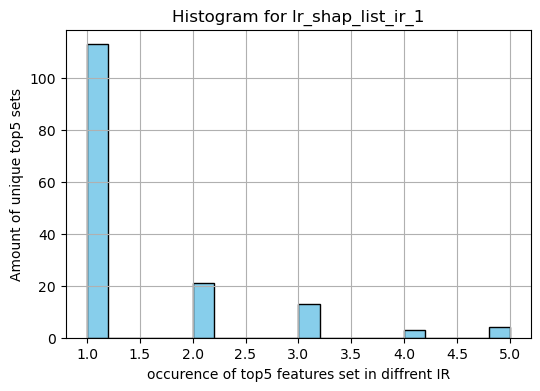

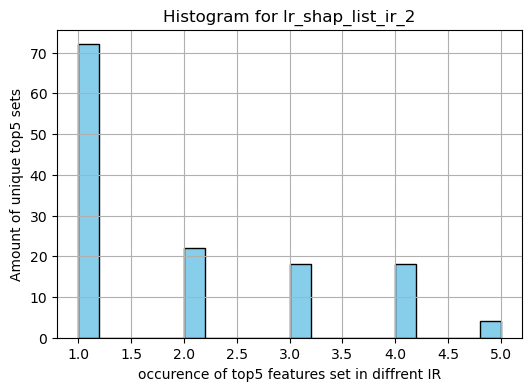

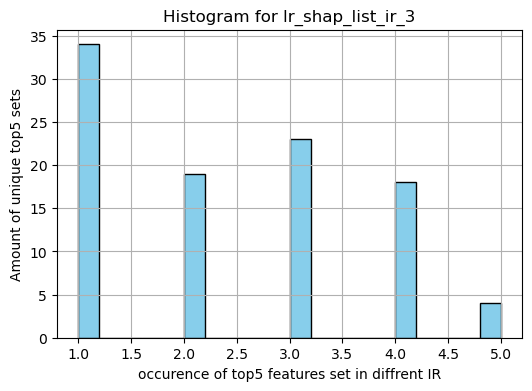

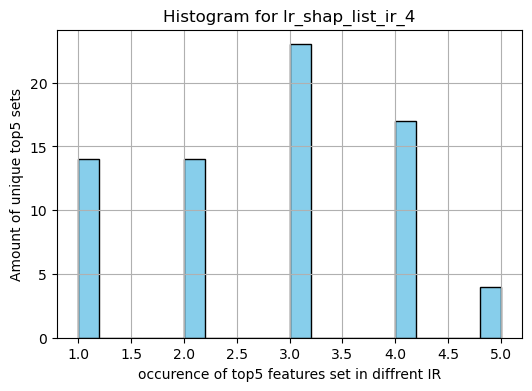

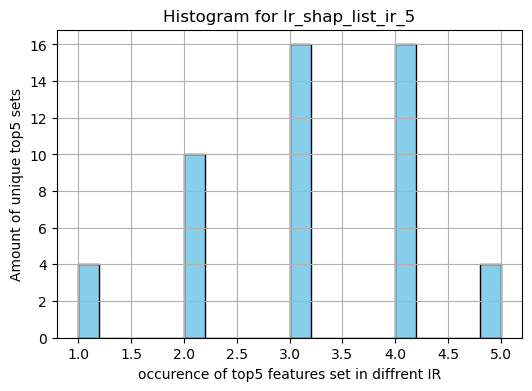

CPU times: total: 875 ms
Wall time: 1.18 s


In [10]:
%%time

# Create histograms for each IR, to evaluate how many unique sets of the most important features was made
for ir_name in imbalanceRatio_columns:
    plt.figure(figsize=(6, 4))  # Set figure size
    plt.hist(unique_feature_lists_df[unique_feature_lists_df['imbalanceRatio']==ir_name]['sum'], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram for {ir_name}')
    plt.xlabel('occurence of top5 features set in diffrent IR')
    plt.ylabel('Amount of unique top5 sets')
    plt.grid(True)
    plt.show()

    
    # Save the histogram as a PNG file in the specified folder
#     filename = os.path.join(output_folder, f"Histogram_for_{feature.replace(' ', '_')}.png")  # Replace spaces with underscores for filenames
#     plt.savefig(filename, dpi=300, bbox_inches='tight')

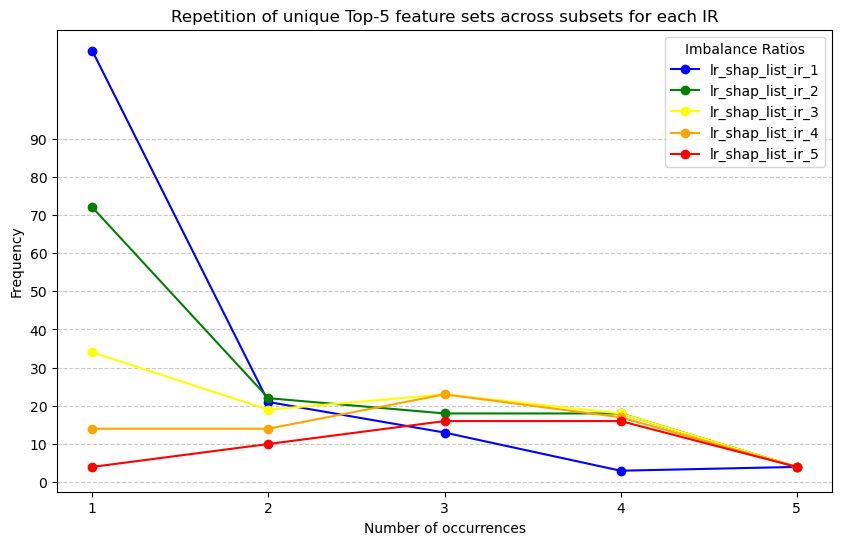

In [13]:
import matplotlib.pyplot as plt
import numpy as np

rank_colors = {1: 'blue', 2: 'green', 3: 'yellow', 4: 'orange', 5: 'red'}
ir_names = unique_feature_lists_df['imbalanceRatio'].unique()
x_values = np.arange(1, 6) 
plt.figure(figsize=(10, 6))

for ir_idx, ir_name in enumerate(ir_names):
    
    rank_counts = [np.sum(unique_feature_lists_df[unique_feature_lists_df['imbalanceRatio'] == ir_name]['sum'] == x) for x in x_values]
    plt.plot(x_values, rank_counts, marker='o', linestyle='-', color=rank_colors.get(ir_idx + 1, 'gray'), label=ir_name)

plt.xlabel('Number of occurrences')
plt.ylabel('Frequency')
plt.title('Repetition of unique Top-5 feature sets across subsets for each IR')
plt.xticks(x_values) 
plt.yticks(np.arange(0, 81 + 10, 10))

plt.legend(title="Imbalance Ratios", loc="upper right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


- Results shows that growing imbalance IR5 => IR1 is shown in different sets of the most significant features.
    - For IR1 models have 40 new, unique sets of the most important features;
    - for IR3 (and less) there is no unique sets for that imbalance ratio 
- there is a trend of less amount of different sets of the most important features, only 8 for IR5, and 

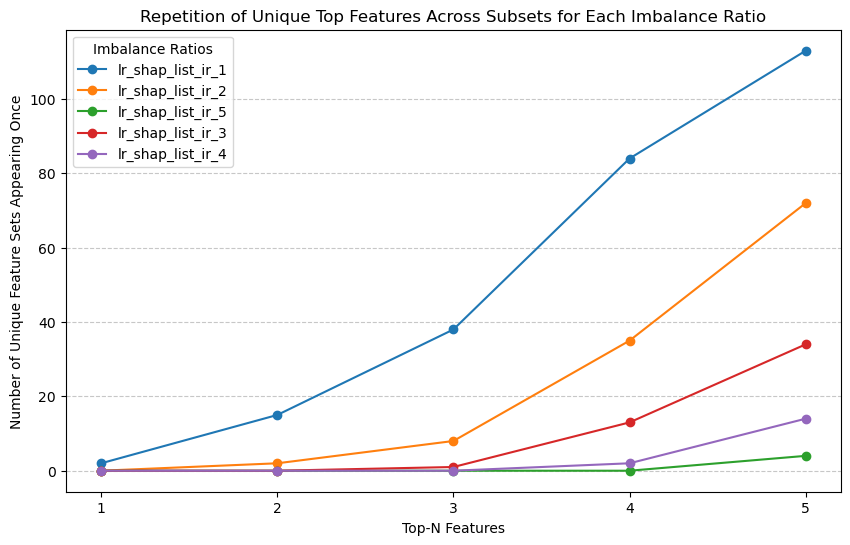

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
file_path = "shap_orderScore_lr.csv"
df = pd.read_csv(file_path)

# Filter only rows where Indicator is 'orderMean'
filtered_df = df[df['Indicator'] == 'orderMean'][['imbalanceRatio', 'Subset', 'Sorted_Features']].copy()

# Function to extract top N features from the Sorted_Features column
def extract_top_features(dataframe, column_name, top_features_amount):
    dataframe[f'top_{top_features_amount}_features'] = dataframe[column_name].apply(
        lambda x: eval(x)[:top_features_amount] if isinstance(x, str) else x[:top_features_amount]
    )
    return dataframe

# Apply the function for top 1 to 5 features
for top_n in range(1, 6):
    filtered_df = extract_top_features(filtered_df, "Sorted_Features", top_n)

# Function to calculate unique feature lists per group
def calculate_unique_feature_lists_per_group(dataframe, group_column, list_column):
    unique_lists_per_group = []
    
    for group, group_df in dataframe.groupby(group_column):
        unique_lists = set(tuple(row) for row in group_df[list_column])
        for unique_list in unique_lists:
            unique_lists_per_group.append({group_column: group, "unique_feature_list": unique_list})
    
    return pd.DataFrame(unique_lists_per_group)

# Process unique feature lists for different top feature amounts
unique_feature_lists = {}
for top_n in range(1, 6):
    unique_feature_lists[top_n] = calculate_unique_feature_lists_per_group(
        filtered_df, "imbalanceRatio", f"top_{top_n}_features"
    )

# Function to add presence columns per imbalance ratio
def add_presence_columns(unique_feature_lists_df, dataframe, group_column, list_column):
    group_values = dataframe[group_column].unique()

    for group in group_values:
        group_features = set(tuple(row) for row in dataframe[dataframe[group_column] == group][list_column])
        unique_feature_lists_df[group] = unique_feature_lists_df["unique_feature_list"].apply(
            lambda x: 1 if x in group_features else 0
        )

    return unique_feature_lists_df

# Add presence columns for each unique feature list dataframe
for top_n in range(1, 6):
    unique_feature_lists[top_n] = add_presence_columns(
        unique_feature_lists[top_n], filtered_df, "imbalanceRatio", f"top_{top_n}_features"
    )

# Summarize occurrences
for top_n in range(1, 6):
    imbalanceRatio_columns = list(unique_feature_lists[top_n]['imbalanceRatio'].unique())
    unique_feature_lists[top_n]['sum'] = unique_feature_lists[top_n][imbalanceRatio_columns].sum(axis=1)

# Generate line plot for unique feature sets appearing exactly once
plt.figure(figsize=(10, 6))
x_values = np.arange(1, 6)  # 1 to 5 features

for ir_name in filtered_df['imbalanceRatio'].unique():
    rank_counts = [
        np.sum(unique_feature_lists[top_n][unique_feature_lists[top_n]['imbalanceRatio'] == ir_name]['sum'] == 1)
        for top_n in range(1, 6)
    ]
    plt.plot(x_values, rank_counts, marker='o', linestyle='-', label=ir_name)

plt.xlabel('Top-N Features')
plt.ylabel('Number of Unique Feature Sets Appearing Once')
plt.title('Repetition of Unique Top Features Across Subsets for Each Imbalance Ratio')
plt.xticks(x_values)
plt.legend(title="Imbalance Ratios", loc="upper left")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


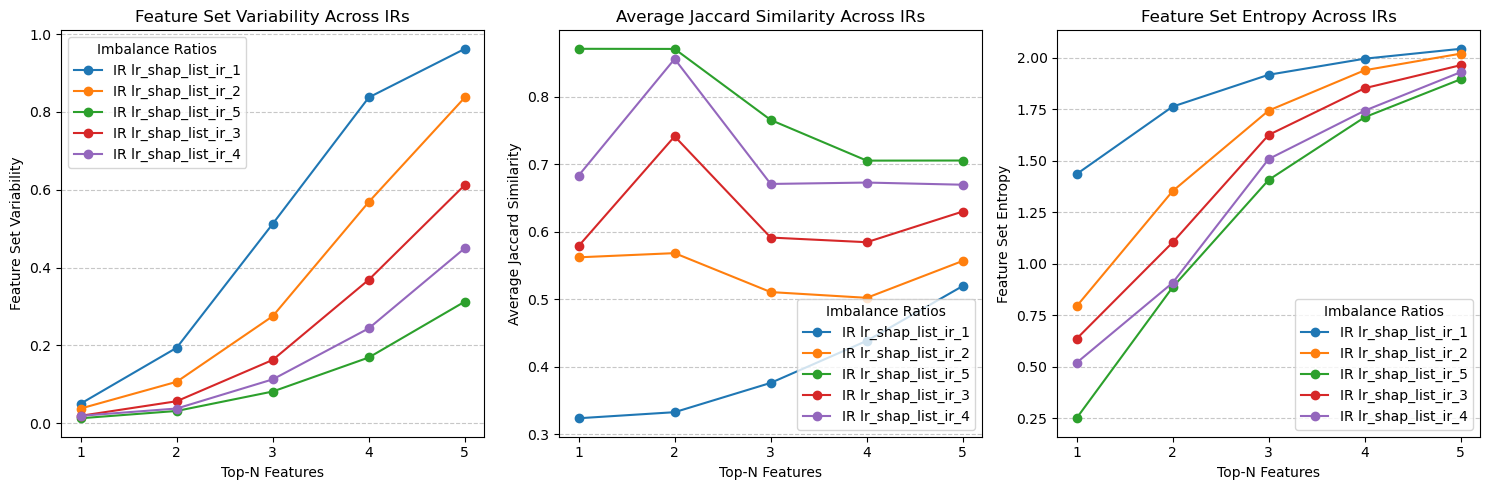

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from sklearn.preprocessing import MultiLabelBinarizer

# Cargar el dataset
file_path = "shap_orderScore_lr.csv"
df = pd.read_csv(file_path)

# Filtrar los datos donde el indicador es 'orderMean'
filtered_df = df[df['Indicator'] == 'orderMean'][['imbalanceRatio', 'Subset', 'Sorted_Features']].copy()

# Función para extraer las k-top características de la columna Sorted_Features
def extract_top_features(dataframe, column_name, top_features_amount):
    dataframe[f'top_{top_features_amount}_features'] = dataframe[column_name].apply(
        lambda x: eval(x)[:top_features_amount] if isinstance(x, str) else x[:top_features_amount]
    )
    return dataframe

# Aplicar la función para los k-top features (k = 1 a 5)
for top_n in range(1, 6):
    filtered_df = extract_top_features(filtered_df, "Sorted_Features", top_n)

# Función para calcular la tasa de variabilidad de conjuntos de características por IR
def calculate_feature_set_variability(dataframe, group_column, list_column):
    variability_dict = {}
    
    for group, group_df in dataframe.groupby(group_column):
        unique_sets = set(tuple(row) for row in group_df[list_column])
        total_sets = len(group_df)
        variability_dict[group] = len(unique_sets) / total_sets  # Ratio de variabilidad
    
    return pd.DataFrame(list(variability_dict.items()), columns=[group_column, 'variability'])

# Función para calcular la similitud de Jaccard promedio entre subsets del mismo IR (corregida)
def calculate_jaccard_similarity(dataframe, group_column, list_column):
    jaccard_dict = {}

    for group, group_df in dataframe.groupby(group_column):
        feature_sets = [set(row) for row in group_df[list_column]]
        
        if len(feature_sets) > 1:
            # Convertir los conjuntos en una matriz binaria usando MultiLabelBinarizer
            mlb = MultiLabelBinarizer()
            binary_matrix = mlb.fit_transform(feature_sets)
            
            # Calcular la distancia de Jaccard correctamente
            jaccard_matrix = 1 - squareform(pdist(binary_matrix, metric='jaccard'))
            avg_jaccard = np.mean(jaccard_matrix[np.triu_indices(len(feature_sets), k=1)])  # Promedio sin la diagonal
        else:
            avg_jaccard = 1  # Si hay solo un subset, la similaridad es 1
        
        jaccard_dict[group] = avg_jaccard
    
    return pd.DataFrame(list(jaccard_dict.items()), columns=[group_column, 'jaccard_similarity'])

# Función para calcular la entropía de los sets de características en cada IR
def calculate_entropy(dataframe, group_column, list_column):
    entropy_dict = {}

    for group, group_df in dataframe.groupby(group_column):
        feature_sets = [tuple(row) for row in group_df[list_column]]
        _, counts = np.unique(feature_sets, return_counts=True)
        prob_dist = counts / counts.sum()
        entropy_value = entropy(prob_dist)  # Entropía de Shannon
        entropy_dict[group] = entropy_value

    return pd.DataFrame(list(entropy_dict.items()), columns=[group_column, 'entropy'])

# Calcular las métricas para k = 1 a 5
results = {}

for top_n in range(1, 6):
    results[top_n] = {
        'variability': calculate_feature_set_variability(filtered_df, "imbalanceRatio", f"top_{top_n}_features"),
        'jaccard': calculate_jaccard_similarity(filtered_df, "imbalanceRatio", f"top_{top_n}_features"),
        'entropy': calculate_entropy(filtered_df, "imbalanceRatio", f"top_{top_n}_features")
    }

# Graficar resultados
plt.figure(figsize=(15, 5))

for i, (metric_name, ylabel) in enumerate(zip(['variability', 'jaccard', 'entropy'],
                                              ['Feature Set Variability', 'Average Jaccard Similarity', 'Feature Set Entropy'])):
    plt.subplot(1, 3, i + 1)
    x_values = np.arange(1, 6)
    
    for ir_name in filtered_df['imbalanceRatio'].unique():
        y_values = [results[top_n][metric_name].set_index("imbalanceRatio").loc[ir_name].values[0] for top_n in range(1, 6)]
        plt.plot(x_values, y_values, marker='o', linestyle='-', label=f'IR {ir_name}')
    
    plt.xlabel('Top-N Features')
    plt.ylabel(ylabel)
    plt.title(ylabel + ' Across IRs')
    plt.xticks(x_values)
    plt.legend(title="Imbalance Ratios", loc="best")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## import numpy as np, pandas as pd
from scipy.stats import entropy

def entropy_boot_ci(df, group_col, list_col, B=1000, alpha=0.05, seed=None):
    rng = np.random.default_rng(seed)
    out = []

    for g, gdf in df.groupby(group_col):
        n = len(gdf)
        boots = []
        arr = gdf[list_col].to_numpy()

        for _ in range(B):
            sample_idx = rng.choice(n, n, replace=True)
            sample_sets = [tuple(arr[i]) for i in sample_idx]
            _, counts = np.unique(sample_sets, return_counts=True)
            boots.append(entropy(counts / counts.sum(), base=np.e))

        lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
        out.append((g, np.mean(boots), lo, hi))

    return pd.DataFrame(out, columns=[group_col, 'entropy', 'ci_lower', 'ci_upper'])


## END of part II
***

In [33]:
import os, re, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dataset_identifiers = ["Covid_code", "Diabetes_code", "Forest_code", "Mammography_code", "Satimage_code"]
# base_path = "../newResults"
base_path = "../"

file_pattern = "sorted_orderValuesScore_*.csv"

DISPLAY_NAMES = {
    "Covid_code": "SMS",
    "Mammography_code": "Mammography",
    "Forest_code": "Forest",
    "Satimage_code": "Satimage",
    "Diabetes_code": "Diabetes"
}

IR_ORDER  = [1, 2, 3, 4, 5]
IR_LABELS = {1: "1:49", 2: "1:19", 3: "1:9", 4: "3:17", 5: "1:4"}
IR_COLORS = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#d62728", 5: "#9467bd"}

FIG_DPI = 600
FIG_FMT = "png"
OUT_DIR = os.path.join(base_path, "figs_TOP3_byFeature_violin_byMethod_2x2")
os.makedirs(OUT_DIR, exist_ok=True)

def parse_ir_subset_covid(s: str):
    
    if not isinstance(s, str):
        return (np.nan, np.nan)
    m = re.search(r'ir[_\-]?(\d+)(?:.*?(?:subset|sub)[_\-]?(\d+))?', s, flags=re.IGNORECASE)
    if m:
        ir = int(m.group(1))
        sub = int(m.group(2)) if m.group(2) is not None else np.nan
        return (f"lr_shap_list_ir_{ir}", sub)
    return (np.nan, np.nan)

def extract_method_from_filename(path: str):
    fname = os.path.basename(path)
    m = re.match(r"sorted_orderValuesScore_(.+)\.csv$", fname, flags=re.IGNORECASE)
    return m.group(1) if m else "unknown"

def ir_str_to_int(ir_str: str):
    if not isinstance(ir_str, str):
        return np.nan
    m = re.search(r'ir[_\-]?(\d+)', ir_str, flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan

def build_long(base_path: str, dataset_ids):
    recs = []
    for dataset in dataset_ids:
        ds_dir = os.path.join(base_path, dataset)
        csvs = glob.glob(os.path.join(ds_dir, file_pattern))
        if not csvs:
            print(f"[WARN] No files for {dataset}")
            continue

        for csv_path in csvs:
            method = extract_method_from_filename(csv_path)
            df = pd.read_csv(csv_path)
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])
            df.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

            if dataset == "Covid_code":
                parsed = df['subset'].apply(parse_ir_subset_covid)
                df['imbalance_ratio'] = parsed.apply(lambda x: x[0])
                df['subset'] = parsed.apply(lambda x: x[1])

            df['IR'] = df['imbalance_ratio'].apply(ir_str_to_int)
            df = df[df['IR'].isin(IR_ORDER)]
            df['IR_label'] = df['IR'].map(IR_LABELS)

            keep = ['feature', 'subset', 'IR', 'IR_label', 'shapMean']
            dd = df[keep].copy()
            dd['dataset'] = dataset
            dd['method']  = method
            recs.append(dd)

    if not recs:
        raise RuntimeError("No data loaded.")
    return pd.concat(recs, ignore_index=True)

def topN_by_dataset(long_df: pd.DataFrame, N=3):
    
    top_map = {}
    for ds, g in long_df.groupby('dataset'):
        imp = (g.assign(a=g['shapMean'].abs())
                 .groupby('feature', as_index=False)['a'].mean()
                 .sort_values('a', ascending=False))
        top_map[ds] = imp['feature'].head(N).tolist()
    return top_map

def plot_dataset_grid_2x2_by_method_violin(long_df: pd.DataFrame, dataset: str,
                                           features, display_labels,
                                           width=0.12, gap_feat=0.35,
                                           show_y_range_in_title=False):
    
    g = long_df[long_df['dataset'] == dataset].copy()
    if g.empty:
        print(f"[WARN] No data for {dataset}")
        return

    methods = sorted(g['method'].unique())
    max_panels = 4
    methods = methods[:max_panels]
    n_panels = len(methods)
    n_rows, n_cols = 2, 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8), sharey=False)
    axes = axes.flatten()

    n_irs = len(IR_ORDER)
    legend_handles = {}
    have_any_handle = False

    for ax_idx in range(n_rows * n_cols):
        ax = axes[ax_idx]
        if ax_idx >= n_panels:
            ax.set_axis_off()
            continue

        method = methods[ax_idx]
        gm = g[g['method'] == method]

        base_feat = np.arange(len(features)) * (n_irs * width + gap_feat)

        for iR, ir in enumerate(IR_ORDER):
            pos = base_feat + iR * width
            data = []
            for feat in features:
                vals = gm[(gm['feature'] == feat) & (gm['IR'] == ir)]['shapMean'].values

                data.append(vals if vals.size else np.array([np.nan]))


            vp = ax.violinplot(
                data,
                positions=pos,
                widths=width * 0.95,
                showmeans=False,
                showextrema=False,
                showmedians=False
            )
            for body in vp['bodies']:
                body.set_facecolor(IR_COLORS[ir])
                body.set_alpha(0.55)
                body.set_edgecolor("none")

            has_valid = any(np.isfinite(v).any() for v in data)
            if has_valid and ir not in legend_handles:
                legend_handles[ir] = vp['bodies'][0]
                have_any_handle = True

            meds = [np.nanmedian(v) if np.isfinite(np.nanmedian(v)) else np.nan for v in data]
            ax.scatter(pos, meds, s=12, zorder=3, edgecolors='k', linewidths=0.3)

        centers = base_feat + (n_irs - 1) * width / 2
        ax.set_xticks(centers)
        ax.set_xticklabels(display_labels, rotation=20, ha='right')
        
        if show_y_range_in_title:
            ymin, ymax = ax.get_ylim()
            ax.set_title(f"{method}\n(range {ymin:.2f}–{ymax:.2f})")
        else:
            ax.set_title(method)
        ax.grid(axis='y', alpha=0.3)
        if ax_idx % n_cols == 0:
            ax.set_ylabel("SHAP")

    dataset_display = DISPLAY_NAMES.get(dataset, dataset)
    fig.suptitle(f"{dataset_display} raw SHAP distributions by IR for Top-3 features",
                 y=0.99, fontsize=13)

    if have_any_handle:
        handles = [legend_handles[i] for i in IR_ORDER if i in legend_handles]
        labels  = [IR_LABELS[i] for i in IR_ORDER if i in legend_handles]
        if handles and labels:
            fig.legend(handles, labels, title="IR (pos:neg)",
                       ncol=len(labels), loc="lower center",
                       bbox_to_anchor=(0.5, -0.05), frameon=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    out_path = os.path.join(OUT_DIR, f"{dataset_display}__TOP3_byFeature__violin_byMethod_2x2.{FIG_FMT}")
    plt.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"[INFO] Saved figure: {out_path}")

long_df = build_long(base_path, dataset_identifiers)

top3_map = topN_by_dataset(long_df, N=3)

display_map = {ds: feats.copy() for ds, feats in top3_map.items()}
if "Covid_code" in top3_map and len(top3_map["Covid_code"]) >= 3:
    display_map["Covid_code"][1] = "SEX"
    display_map["Covid_code"][2] = "ARTERIAL_HIPERTENSION"

rows = []
for ds in dataset_identifiers:
    feats = top3_map.get(ds, [])
    disp  = display_map.get(ds, feats)
    for i, (orig, lab) in enumerate(zip(feats, disp), start=1):
        rows.append({
            "dataset": ds,
            "dataset_display": DISPLAY_NAMES.get(ds, ds),
            "rank": i,
            "feature_original": orig,
            "feature_display": lab
        })
pd.DataFrame(rows).to_csv(os.path.join(OUT_DIR, "top3_features_by_dataset.csv"), index=False)

for ds in dataset_identifiers:
    feats = top3_map.get(ds, [])
    if not feats:
        print(f"[WARN] No Top-3 for {ds}"); continue
    labels = display_map.get(ds, feats)
    plot_dataset_grid_2x2_by_method_violin(long_df, ds, features=feats, display_labels=labels,
                                           width=0.12, gap_feat=0.35,
                                           show_y_range_in_title=False)


[WARN] No files for Covid_code
[WARN] No Top-3 for Covid_code
[INFO] Saved figure: ../figs_TOP3_byFeature_violin_byMethod_2x2\Diabetes__TOP3_byFeature__violin_byMethod_2x2.png
[INFO] Saved figure: ../figs_TOP3_byFeature_violin_byMethod_2x2\Forest__TOP3_byFeature__violin_byMethod_2x2.png
[INFO] Saved figure: ../figs_TOP3_byFeature_violin_byMethod_2x2\Mammography__TOP3_byFeature__violin_byMethod_2x2.png
[INFO] Saved figure: ../figs_TOP3_byFeature_violin_byMethod_2x2\Satimage__TOP3_byFeature__violin_byMethod_2x2.png


In [16]:
# 1️⃣ Podstawowe info o kolumnach i typach
long_df.info()

# 2️⃣ Podejrzenie kilku pierwszych wierszy
long_df.head(10)

# 3️⃣ Sprawdzenie, czy są duplikaty dla tych samych (dataset, method, feature, IR)
dupes = (long_df
         .groupby(['dataset', 'method', 'feature', 'IR'])
         .size()
         .reset_index(name='count')
         .sort_values('count', ascending=False)
)
dupes.head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169800 entries, 0 to 169799
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   feature   169800 non-null  object 
 1   subset    169800 non-null  object 
 2   IR        169800 non-null  int64  
 3   IR_label  169800 non-null  object 
 4   shapMean  169800 non-null  float64
 5   dataset   169800 non-null  object 
 6   method    169800 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 9.1+ MB


,dataset,method,feature,IR,count
7,Diabetes_code,lr,BMI,3,160
39,Diabetes_code,lr,SkinThickness,5,160
38,Diabetes_code,lr,SkinThickness,4,160
37,Diabetes_code,lr,SkinThickness,3,160
36,Diabetes_code,lr,SkinThickness,2,160
35,Diabetes_code,lr,SkinThickness,1,160
34,Diabetes_code,lr,Pregnancies,5,160
33,Diabetes_code,lr,Pregnancies,4,160
32,Diabetes_code,lr,Pregnancies,3,160
31,Diabetes_code,lr,Pregnancies,2,160


***
# The whole thing
***

In [34]:
# =======================
# Imports & configuration
# =======================
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import Dropdown, IntSlider, Checkbox, HBox, VBox, Output, Layout, interactive_output
from IPython.display import display, clear_output

# --- datasets & paths ---
dataset_identifiers = ["Covid_code", "Diabetes_code", "Forest_code", "Mammography_code", "Satimage_code"]
base_path = "../"   # <- dostosuj w razie potrzeby
file_pattern = "sorted_orderValuesScore_*.csv"

DISPLAY_NAMES = {
    "Covid_code": "SMS",
    "Mammography_code": "Mammography",
    "Forest_code": "Forest",
    "Satimage_code": "Satimage",
    "Diabetes_code": "Diabetes"
}

IR_ORDER  = [1, 2, 3, 4, 5]
IR_LABELS = {1: "1:49", 2: "1:19", 3: "1:9", 4: "3:17", 5: "1:4"}
IR_COLORS = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c", 4: "#d62728", 5: "#9467bd"}

FIG_DPI = 600
FIG_FMT = "png"
OUT_DIR = os.path.join(base_path, "figs_TOP3_byFeature_violin_byMethod_2x2")
os.makedirs(OUT_DIR, exist_ok=True)

# =======================
# Helpers (same as original)
# =======================
def parse_ir_subset_covid(s: str):
    if not isinstance(s, str):
        return (np.nan, np.nan)
    m = re.search(r'ir[_\-]?(\d+)(?:.*?(?:subset|sub)[_\-]?(\d+))?', s, flags=re.IGNORECASE)
    if m:
        ir = int(m.group(1))
        sub = int(m.group(2)) if m.group(2) is not None else np.nan
        return (f"lr_shap_list_ir_{ir}", sub)
    return (np.nan, np.nan)

def extract_method_from_filename(path: str):
    fname = os.path.basename(path)
    m = re.match(r"sorted_orderValuesScore_(.+)\.csv$", fname, flags=re.IGNORECASE)
    return m.group(1) if m else "unknown"

def ir_str_to_int(ir_str: str):
    if not isinstance(ir_str, str):
        return np.nan
    m = re.search(r'ir[_\-]?(\d+)', ir_str, flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan

def build_long(base_path: str, dataset_ids):
    recs = []
    for dataset in dataset_ids:
        ds_dir = os.path.join(base_path, dataset)
        csvs = glob.glob(os.path.join(ds_dir, file_pattern))
        if not csvs:
            print(f"[WARN] No files for {dataset}")
            continue

        for csv_path in csvs:
            method = extract_method_from_filename(csv_path)
            df = pd.read_csv(csv_path)
            if "Unnamed: 0" in df.columns:
                df = df.drop(columns=["Unnamed: 0"])
            df.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

            if dataset == "Covid_code":
                parsed = df['subset'].apply(parse_ir_subset_covid)
                df['imbalance_ratio'] = parsed.apply(lambda x: x[0])
                df['subset'] = parsed.apply(lambda x: x[1])

            df['IR'] = df['imbalance_ratio'].apply(ir_str_to_int)
            df = df[df['IR'].isin(IR_ORDER)]
            df['IR_label'] = df['IR'].map(IR_LABELS)

            keep = ['feature', 'subset', 'IR', 'IR_label', 'shapMean']
            dd = df[keep].copy()
            dd['dataset'] = dataset
            dd['method']  = method
            recs.append(dd)

    if not recs:
        raise RuntimeError("No data loaded.")
    return pd.concat(recs, ignore_index=True)

def topN_by_dataset(long_df: pd.DataFrame, N=3):
    top_map = {}
    for ds, g in long_df.groupby('dataset'):
        imp = (g.assign(a=g['shapMean'].abs())
                 .groupby('feature', as_index=False)['a'].mean()
                 .sort_values('a', ascending=False))
        top_map[ds] = imp['feature'].head(N).tolist()
    return top_map

# =======================
# Original plotting (Matplotlib 2x2), with small params
# =======================
def plot_dataset_grid_2x2_by_method_violin(long_df: pd.DataFrame, dataset: str,
                                           features, display_labels,
                                           width=0.12, gap_feat=0.35,
                                           show_y_range_in_title=False,
                                           save_to_file=False):
    g = long_df[long_df['dataset'] == dataset].copy()
    if g.empty:
        print(f"[WARN] No data for {dataset}")
        return

    methods = sorted(g['method'].unique())
    max_panels = 4
    methods = methods[:max_panels]
    n_panels = len(methods)
    n_rows, n_cols = 2, 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8), sharey=False)
    axes = axes.flatten()

    n_irs = len(IR_ORDER)
    legend_handles = {}
    have_any_handle = False

    for ax_idx in range(n_rows * n_cols):
        ax = axes[ax_idx]
        if ax_idx >= n_panels:
            ax.set_axis_off()
            continue

        method = methods[ax_idx]
        gm = g[g['method'] == method]

        base_feat = np.arange(len(features)) * (n_irs * width + gap_feat)

        for iR, ir in enumerate(IR_ORDER):
            pos = base_feat + iR * width
            data = []
            for feat in features:
                vals = gm[(gm['feature'] == feat) & (gm['IR'] == ir)]['shapMean'].values
                data.append(vals if vals.size else np.array([np.nan]))

            vp = ax.violinplot(
                data,
                positions=pos,
                widths=width * 0.95,
                showmeans=False,
                showextrema=False,
                showmedians=False
            )
            for body in vp['bodies']:
                body.set_facecolor(IR_COLORS[ir])
                body.set_alpha(0.55)
                body.set_edgecolor("none")

            has_valid = any(np.isfinite(v).any() for v in data)
            if has_valid and ir not in legend_handles:
                legend_handles[ir] = vp['bodies'][0]
                have_any_handle = True

            meds = [np.nanmedian(v) if np.isfinite(np.nanmedian(v)) else np.nan for v in data]
            ax.scatter(pos, meds, s=12, zorder=3, edgecolors='k', linewidths=0.3)

        centers = base_feat + (n_irs - 1) * width / 2
        ax.set_xticks(centers)
        ax.set_xticklabels(display_labels, rotation=20, ha='right')

        if show_y_range_in_title:
            ymin, ymax = ax.get_ylim()
            ax.set_title(f"{method}\n(range {ymin:.2f}–{ymax:.2f})")
        else:
            ax.set_title(method)

        ax.grid(axis='y', alpha=0.3)
        if ax_idx % n_cols == 0:
            ax.set_ylabel("SHAP")

    dataset_display = DISPLAY_NAMES.get(dataset, dataset)
    fig.suptitle(f"{dataset_display} raw SHAP distributions by IR for Top-3 features",
                 y=0.99, fontsize=13)

    if have_any_handle:
        handles = [legend_handles[i] for i in IR_ORDER if i in legend_handles]
        labels  = [IR_LABELS[i] for i in IR_ORDER if i in legend_handles]
        if handles and labels:
            fig.legend(handles, labels, title="IR (pos:neg)",
                       ncol=len(labels), loc="lower center",
                       bbox_to_anchor=(0.5, -0.05), frameon=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save_to_file:
        out_path = os.path.join(OUT_DIR, f"{dataset_display}__TOP3_byFeature__violin_byMethod_2x2.{FIG_FMT}")
        plt.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
        print(f"[INFO] Saved figure: {out_path}")

    plt.show()

# =======================
# Build data once
# =======================
long_df = build_long(base_path, dataset_identifiers)

# =======================
# Widgets UI
# =======================
w_ds = Dropdown(
    options=[(DISPLAY_NAMES.get(ds, ds), ds) for ds in dataset_identifiers],
    value=dataset_identifiers[0],
    description="Dataset:",
    layout=Layout(width="280px")
)
w_topn = IntSlider(value=3, min=1, max=6, step=1, description="Top-N:", continuous_update=False, layout=Layout(width="260px"))
w_save = Checkbox(value=False, description="Save to file")
w_showyr = Checkbox(value=False, description="Show Y-range in titles")
out = Output()

def recompute_and_plot(dataset, topn, save_to_file, show_y_range_in_title):
    out.clear_output(wait=True)
    with out:
        # compute top-N per dataset
        top_map = topN_by_dataset(long_df, N=topn)
        feats = top_map.get(dataset, [])
        if not feats:
            print(f"[WARN] No Top-{topn} for {dataset}")
            return

        # display labels (keep your Covid replacements)
        labels = feats.copy()
        if dataset == "Covid_code" and len(labels) >= 3:
            labels[1] = "SEX"
            labels[2] = "ARTERIAL_HIPERTENSION"

        plot_dataset_grid_2x2_by_method_violin(
            long_df, dataset,
            features=feats, display_labels=labels,
            width=0.12, gap_feat=0.35,
            show_y_range_in_title=show_y_range_in_title,
            save_to_file=save_to_file
        )

controls = {
    'dataset': w_ds,
    'topn': w_topn,
    'save_to_file': w_save,
    'show_y_range_in_title': w_showyr
}
io = interactive_output(recompute_and_plot, controls)

ui = VBox([HBox([w_ds, w_topn, w_save, w_showyr]), out])
display(ui)

# initial draw
recompute_and_plot(w_ds.value, w_topn.value, w_save.value, w_showyr.value)


[WARN] No files for Covid_code
